In [58]:
import numpy as np
import os
import time
import scipy
import pybullet as p
import pybullet_data
import matplotlib.pyplot as plt
import pickle
from mpl_toolkits.mplot3d import Axes3D

In [59]:
gmm_5 = pickle.load(open("gmm_models/gmm_5", "rb"))
gmm_6 = pickle.load(open("gmm_models/gmm_6", "rb"))

In [60]:
X_des = np.array([0.5, 0.4, 0.2])
phi_des = 1

In [61]:
pred_6 = gmm_6.predict(np.array([0,1,2]), X_des.reshape(-1,1).T)
pred_5 = gmm_5.predict(np.array([0,1,2]), X_des.reshape(-1,1).T)

In [62]:
print(pred_5)

[[3.68875157 1.55077182]]


In [63]:
print(pred_6)


[[2.27372901 1.71216443]]


In [64]:
m_range = np.linspace(0.1, 3, 100)
phi_range = np.linspace(0.5, 1.5, 50)

m_grid, phi_grid = np.meshgrid(m_range, phi_range)
m_sparse, phi_sparse = np.meshgrid(m_range, phi_range, sparse=True)

In [65]:
check_6 = pred_6[0][1] >= phi_grid * ( m_grid / pred_6[0][0] + 1 )
check_5 = pred_5[0][1] >= phi_grid * ( m_grid / pred_5[0][0] + 1 )

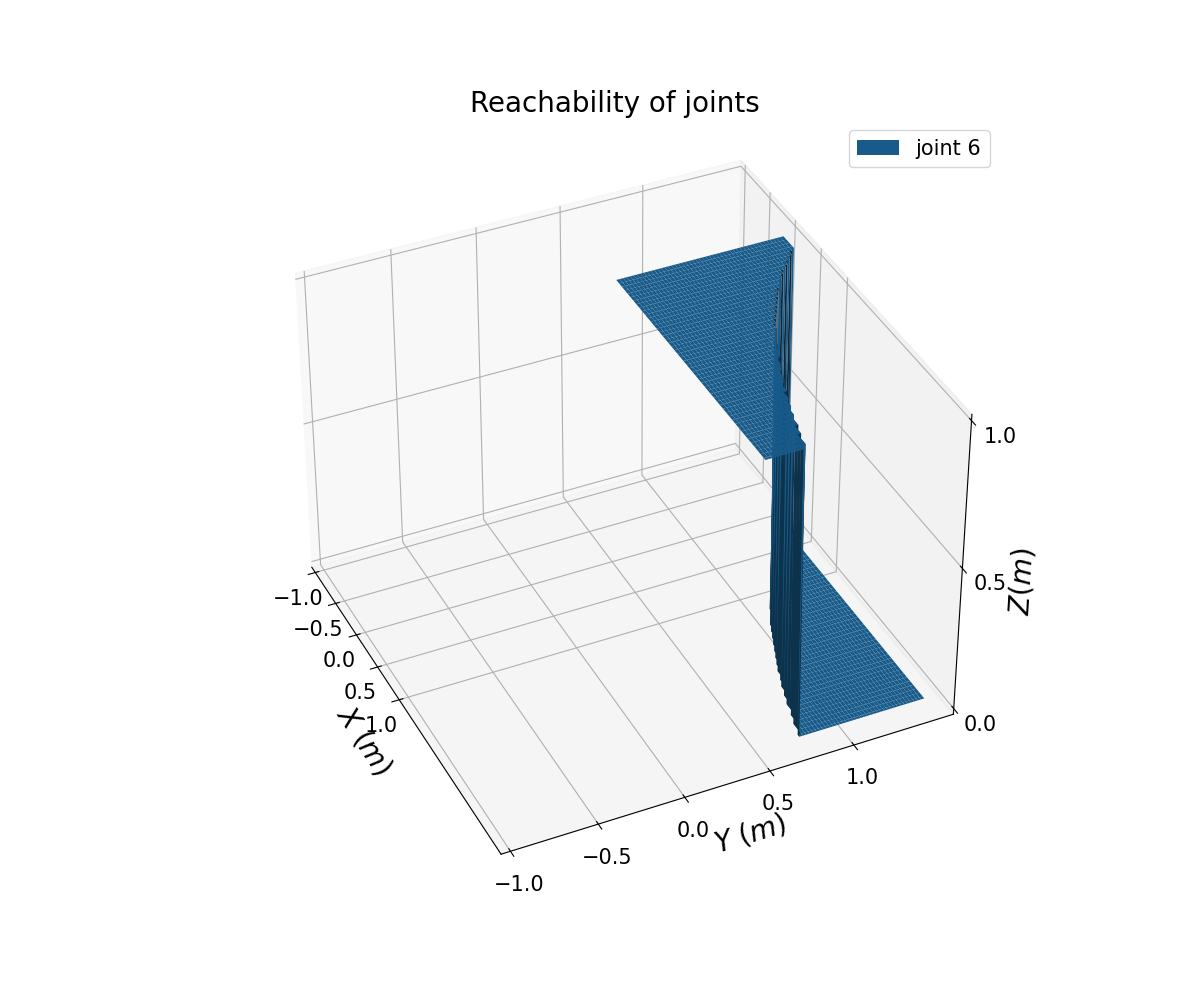

In [68]:
# %matplotlib notebook
%matplotlib widget
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(projection='3d')

ax.plot_surface(m_grid, phi_grid, check_6)
# ax.set_xlabel('$X$ $(m)$', fontsize = 20)
# ax.set_ylabel('$Y$ $(m)$', fontsize = 20)
# ax.set_zlabel('$Z (m)$', fontsize = 20)
# ax.set_xticks([-1, -0.5, 0, 0.5, 1])
# ax.set_yticks([-1, -0.5, 0, 0.5, 1])
# ax.set_zticks([0, 0.5, 1])
# ax.view_init(elev=37, azim=-25)

# ax.yaxis._axinfo['label']['space_factor'] = 3.0
# ax.xaxis._axinfo['label']['space_factor'] = 3.0

# ax.tick_params(axis='both', which='major', labelsize=15)
# ax.legend(['joint 6', 'joint 5'], fontsize=15)
# ax.set_title("Reachability of joints", fontsize=20)

plt.show()